# Pairing + Particle–Hole Model: RPA and QRPA

**Companion to `pairing_ph_exact_diag.ipynb`.**

In the exact-diagonalization notebook we solved the schematic Hamiltonian of Sec. 2.1 of
*Hjorth-Jensen, Dean, Hagen, Kvaal, J. Phys. G **37**, 064035 (2010)* exactly.
Here we add two of the workhorse approximate many-body methods and compare them, term by term,
against the exact spectrum:

1. **Tamm–Dancoff (TDA)** and the **Random Phase Approximation (RPA)** built on the Hartree–Fock ground state — the particle–hole (ph) channel.
2. **BCS** plus the **Quasiparticle RPA (QRPA)** built on the BCS vacuum — the pairing (particle–particle) channel.

The model Hamiltonian, with $L$ doubly-degenerate equidistant levels $p=1,\dots,L$ (spin $\sigma=\pm$) and $N$ fermions, is
$$
\hat H=\hat H_0+\hat V_{\rm pair}+\hat V_{\rm ph},\qquad
\hat H_0=\xi\sum_{p\sigma}(p-1)\,a^\dagger_{p\sigma}a_{p\sigma},
$$
$$
\hat V_{\rm pair}=-\tfrac{g}{2}\sum_{pq}a^\dagger_{p+}a^\dagger_{p-}a_{q-}a_{q+},\qquad
\hat V_{\rm ph}=-\tfrac{f}{2}\sum_{pqr}\Big(a^\dagger_{p+}a^\dagger_{p-}a_{q-}a_{r+}+\text{h.c.}\Big).
$$
Both interactions conserve $N_+$ and $N_-$ separately, so $S_z$ is a good quantum number.
Throughout we take $\xi=1$ and the reference case $N=L=4$, and study the two regimes used in the paper,
$f=0.05\,g$ (weak ph) and $f=0.5\,g$ (strong ph), plus the clean **pure-pairing** case $f=0$.

> **Design note.** Every quantity below is assembled from *second-quantised operators represented as
> sparse matrices in the full $2^{2L}$-dimensional Fock space*. This keeps the code close to the algebra:
> the RPA/QRPA matrices are evaluated as literal ground-state expectation values of double commutators,
> $A_{KL}=\langle 0|[\hat O_K^\dagger,[\hat H,\hat O_L]]|0\rangle$, with no hand-transcribed matrix-element
> formulas to get wrong. Once validated, the performance-critical kernels are the natural targets for a
> C++/Fortran port (a later step).

In [1]:
import numpy as np
from itertools import combinations
from scipy.sparse import csr_matrix
from scipy.linalg import eigh, eig
from scipy.optimize import minimize
import matplotlib.pyplot as plt

np.set_printoptions(precision=4, suppress=True)

# ---- spin-orbital bookkeeping ----
UP, DN = 0, 1
def oidx(level, spin):   # level=1..L, spin in {UP,DN}  ->  0..2L-1
    return 2*(level-1) + spin
def lvl(o):
    return o//2 + 1

## 1. Fock-space engine

We build creation operators $a^\dagger_o$ as $2^{2L}\times 2^{2L}$ sparse matrices in the occupation-number
basis, with the Jordan–Wigner string $(-1)^{\sum_{o'<o} n_{o'}}$ enforcing fermion antisymmetry. Everything
else — the Hamiltonian, the number operator, HF/BCS references, quasiparticles — is composed from these.

In [2]:
def build_c_ops(L):
    '''Return lists of creation (cdag) and annihilation (c) operators as sparse matrices,
    plus the Fock-space dimension 2^{2L}.'''
    norb = 2*L
    dim = 1 << norb
    cdag = []
    for o in range(norb):
        rows, cols, data = [], [], []
        for s in range(dim):
            if (s >> o) & 1:            # orbital already occupied -> a^dag gives 0
                continue
            sign = -1 if (bin(s & ((1 << o) - 1)).count("1") & 1) else 1
            t = s | (1 << o)
            rows.append(t); cols.append(s); data.append(sign)
        cdag.append(csr_matrix((data, (rows, cols)), shape=(dim, dim)))
    c = [cd.T.tocsr() for cd in cdag]
    return cdag, c, dim

def build_H_fock(L, g, f, xi=1.0):
    '''Full Hamiltonian H0 + Vpair + Vph as a sparse matrix in Fock space.'''
    cdag, c, dim = build_c_ops(L)
    H = csr_matrix((dim, dim))
    for p in range(1, L+1):
        for s in (UP, DN):
            H = H + xi*(p-1)*(cdag[oidx(p,s)] @ c[oidx(p,s)])
    for p in range(1, L+1):                                   # pairing
        Pd = cdag[oidx(p,UP)] @ cdag[oidx(p,DN)]
        for q in range(1, L+1):
            Pq = c[oidx(q,DN)] @ c[oidx(q,UP)]
            H = H + (-0.5*g)*(Pd @ Pq)
    for p in range(1, L+1):                                   # particle-hole (+ h.c.)
        Pd = cdag[oidx(p,UP)] @ cdag[oidx(p,DN)]
        for q in range(1, L+1):
            for r in range(1, L+1):
                op = Pd @ c[oidx(q,DN)] @ c[oidx(r,UP)]
                H = H + (-0.5*f)*(op + op.conj().T)
    return H, cdag, c, dim

def number_sector_indices(L, N):
    norb = 2*L
    return np.array([s for s in range(1 << norb) if bin(s).count("1") == N])

def exact_spectrum(L, N, g, f, k=8, xi=1.0):
    H, *_ = build_H_fock(L, g, f, xi)
    idx = number_sector_indices(L, N)
    Hsec = H[np.ix_(idx, idx)].toarray()
    return np.sort(np.linalg.eigvalsh(Hsec))[:k]

# sanity check against the exact-diagonalisation notebook
L, N = 4, 4
print("exact lowest levels (g=0.7, f=0.05):", exact_spectrum(L, N, 0.7, 0.05, k=4))

exact lowest levels (g=0.7, f=0.05): [0.9698 2.5669 2.5678 2.5678]


## 2. Hartree–Fock reference

RPA is a small-amplitude expansion around a *stationary* mean field, so we first solve Hartree–Fock.
We need the antisymmetrised two-body matrix elements $\bar v_{abcd}=\langle ab|\hat V|cd\rangle_{\rm AS}$,
which we read directly off the two-particle sector of $\hat V=\hat H-\hat H_0$:
$$
\bar v_{abcd}=\big(a^\dagger_a a^\dagger_b|0\rangle\big)^\dagger\,\hat V\,\big(a^\dagger_c a^\dagger_d|0\rangle\big).
$$
The HF field is $F_{ab}=t_{ab}+\sum_{cd}\bar v_{acbd}\,\rho_{dc}$ with $\rho=\sum_{i\in{\rm occ}}C_{\cdot i}C^*_{\cdot i}$,
iterated to self-consistency.

For this model a useful fact emerges: with **pure pairing** ($f=0$) the filled Fermi sea is *exactly* HF
(Brillouin's theorem $\langle\text{1p1h}|\hat H|\text{HF}\rangle=0$ holds), whereas the ph term induces a
mean-field 1p1h coupling of size $f/2$ that HF must rotate away.

In [3]:
def build_vbar(L, g, f, xi=1.0):
    '''Antisymmetrised two-body matrix elements vbar[a,b,c,d] of V = H - H0.'''
    cdag, c, dim = build_c_ops(L)
    norb = 2*L
    H, *_ = build_H_fock(L, g, f, xi)
    H0 = csr_matrix((dim, dim))
    for p in range(1, L+1):
        for s in (UP, DN):
            H0 = H0 + xi*(p-1)*(cdag[oidx(p,s)] @ c[oidx(p,s)])
    V = H - H0
    vac = np.zeros(dim); vac[0] = 1.0
    kets = {(a,b): cdag[a] @ (cdag[b] @ vac) for a in range(norb) for b in range(norb)}
    vbar = np.zeros((norb,)*4)
    for a in range(norb):
        for b in range(norb):
            bra = kets[(a,b)]
            for cc in range(norb):
                for dd in range(norb):
                    vbar[a,b,cc,dd] = bra @ (V @ kets[(cc,dd)])
    return vbar

def eps0(L, xi=1.0):
    return np.array([xi*(lvl(o)-1) for o in range(2*L)])

def hartree_fock(L, N, g, f, xi=1.0, iters=300, tol=1e-11):
    norb = 2*L
    t = np.diag(eps0(L, xi))
    vbar = build_vbar(L, g, f, xi)
    C = np.eye(norb); e_old = None
    for _ in range(iters):
        rho = sum(np.outer(C[:,i], C[:,i]) for i in range(N))
        F = t + np.einsum('acbd,dc->ab', vbar, rho)
        eps, C = eigh(F)
        if e_old is not None and abs(eps.sum()-e_old) < tol:
            break
        e_old = eps.sum()
    rho = sum(np.outer(C[:,i], C[:,i]) for i in range(N))
    E1 = np.einsum('ab,ab->', t, rho)
    E2 = 0.5*sum(np.einsum('a,b,c,d,abcd->', C[:,i], C[:,j], C[:,i], C[:,j], vbar)
                 for i in range(N) for j in range(N))
    return eps, C, E1+E2, vbar

for (g, f) in [(0.7, 0.0), (0.7, 0.05), (1.0, 0.5)]:
    eps, C, Ehf, _ = hartree_fock(L, N, g, f)
    print(f"g={g}, f={f}:  E_HF={Ehf:8.5f}   HF s.p. energies={eps}")

g=0.7, f=0.0:  E_HF= 1.30000   HF s.p. energies=[-0.35 -0.35  0.65  0.65  2.    2.    3.    3.  ]
g=0.7, f=0.05:  E_HF= 1.19709   HF s.p. energies=[-0.4043 -0.4043  0.5999  0.5999  1.9991  1.9991  2.9995  2.9995]


g=1.0, f=0.5:  E_HF=-0.26976   HF s.p. energies=[-1.5052 -1.5052  0.1194  0.1194  1.9305  1.9305  2.9534  2.9534]


## 3. Tamm–Dancoff and RPA (particle–hole channel)

Introduce the phonon creation operator
$$
\hat Q^\dagger_\nu=\sum_{mi}\Big(X^\nu_{mi}\,a^\dagger_m a_i-Y^\nu_{mi}\,a^\dagger_i a_m\Big),
$$
where $i,j,\dots$ run over occupied (hole) and $m,n,\dots$ over unoccupied (particle) HF orbitals.
Demanding $[\hat H,\hat Q^\dagger_\nu]=\omega_\nu \hat Q^\dagger_\nu$ to leading order in the quasiboson
approximation gives the **RPA eigenvalue problem**
$$
\begin{pmatrix} A & B\\ -B^* & -A^*\end{pmatrix}
\begin{pmatrix} X^\nu\\ Y^\nu\end{pmatrix}
=\omega_\nu\begin{pmatrix} X^\nu\\ Y^\nu\end{pmatrix},
$$
with
$$
A_{mi,nj}=\langle{\rm HF}|[\,a^\dagger_i a_m,[\hat H,a^\dagger_n a_j]\,]|{\rm HF}\rangle
=(\varepsilon_m-\varepsilon_i)\delta_{mn}\delta_{ij}+\bar v_{mjin},
$$
$$
B_{mi,nj}=-\langle{\rm HF}|[\,a^\dagger_i a_m,[\hat H,a^\dagger_j a_n]\,]|{\rm HF}\rangle=\bar v_{mnij}.
$$
Setting $B=0$ (i.e. neglecting the ground-state correlations carried by $Y$) recovers the **Tamm–Dancoff
approximation**, $A X=\omega X$. The RPA ground state is correlated, and its energy relative to HF is
$$
E^{\rm RPA}_{\rm corr}=\tfrac12\Big(\sum_\nu\omega_\nu-\operatorname{Tr}A\Big).
$$
We evaluate $A$ and $B$ *directly as the double commutators above* — valid for any reference — after
rotating the elementary operators into the self-consistent HF basis.

In [4]:
def commutator(X, Y):
    return X @ Y - Y @ X

def build_AB(H, ref, Oops):
    '''A_KL=<0|[O_K^dag,[H,O_L]]|0>,  B_KL=-<0|[O_K^dag,[H,O_L^dag]]|0>  for reference |0>=ref.'''
    n = len(Oops)
    A = np.zeros((n, n)); B = np.zeros((n, n))
    HO  = [commutator(H, O)             for O in Oops]
    HOd = [commutator(H, O.conj().T)    for O in Oops]
    Od  = [O.conj().T                   for O in Oops]
    for k in range(n):
        left = ref @ Od[k]
        for l in range(n):
            A[k, l] =  left @ (HO[l]  @ ref) - ref @ (HO[l]  @ (Od[k] @ ref))
            B[k, l] = -(left @ (HOd[l] @ ref) - ref @ (HOd[l] @ (Od[k] @ ref)))
    return A, B

def solve_rpa(A, B, tol=1e-6):
    '''Return (sorted positive real omegas, #imaginary modes, full spectrum).'''
    M = np.block([[A, B], [-B.conj(), -A.conj()]])
    w = eig(M, right=False)
    n_imag = int(np.sum(np.abs(w.imag) > 1e-6))
    real = w[np.abs(w.imag) < 1e-6].real
    pos = np.sort(real[real > tol])
    return pos, n_imag, w

def hf_basis_ops(L, C):
    '''Creation/annihilation operators rotated into the HF single-particle basis.'''
    cdag, c, dim = build_c_ops(L)
    norb = 2*L
    tdag = []
    for a in range(norb):
        op = csr_matrix((dim, dim))
        for o in range(norb):
            if abs(C[o, a]) > 1e-14:
                op = op + C[o, a]*cdag[o]
        tdag.append(op.tocsr())
    tann = [op.conj().T.tocsr() for op in tdag]
    vac = np.zeros(dim); vac[0] = 1.0
    return tdag, tann, vac, dim

def hf_reference_vec(tdag, vac, N):
    v = vac.copy()
    for i in range(N):
        v = tdag[i] @ v
    return v/np.linalg.norm(v)

def rpa_ph(L, N, g, f, xi=1.0):
    eps, C, Ehf, _ = hartree_fock(L, N, g, f, xi)
    H, *_ = build_H_fock(L, g, f, xi)
    tdag, tann, vac, dim = hf_basis_ops(L, C)
    ref = hf_reference_vec(tdag, vac, N)
    parts, holes = range(N, 2*L), range(N)
    Oops = [tdag[m] @ tann[i] for m in parts for i in holes]   # a^dag_m a_i
    A, B = build_AB(H, ref, Oops)
    tda = np.sort(np.linalg.eigvalsh(A))
    rpa, n_imag, _ = solve_rpa(A, B)
    Ecorr = 0.5*(rpa.sum() - np.trace(A))
    return dict(Ehf=Ehf, tda=tda, rpa=rpa, Ecorr=Ecorr, n_imag=n_imag, A=A, B=B)

# demonstration
g, f = 0.7, 0.05
r  = rpa_ph(L, N, g, f)
ex = exact_spectrum(L, N, g, f, k=4)
print(f"g={g}, f={f}")
print(f"  E_HF            = {r['Ehf']:.5f}")
print(f"  E_HF + E_corr   = {r['Ehf']+r['Ecorr']:.5f}   (RPA correlated ground state)")
print(f"  exact  E0       = {ex[0]:.5f}")
print(f"  lowest TDA omega = {r['tda'][0]:.4f}")
print(f"  lowest RPA omega = {r['rpa'][0]:.4f}")
print(f"  exact  E1 - E0   = {ex[1]-ex[0]:.4f}")

g=0.7, f=0.05
  E_HF            = 1.19709
  E_HF + E_corr   = 0.89759   (RPA correlated ground state)
  exact  E0       = 0.96976
  lowest TDA omega = 1.3992
  lowest RPA omega = 1.3412
  exact  E1 - E0   = 1.5972


### RPA/TDA across the coupling

The next figure tracks the ground-state energy and the lowest excitation as functions of $g$. RPA lowers
the energy below HF (ground-state correlations) and typically *overbinds* — dipping slightly below the
exact curve — while both TDA and RPA place the lowest ph phonon below the exact first excitation, because
the ph channel alone does not know about the pairing correlations that shape the true low-lying spectrum.

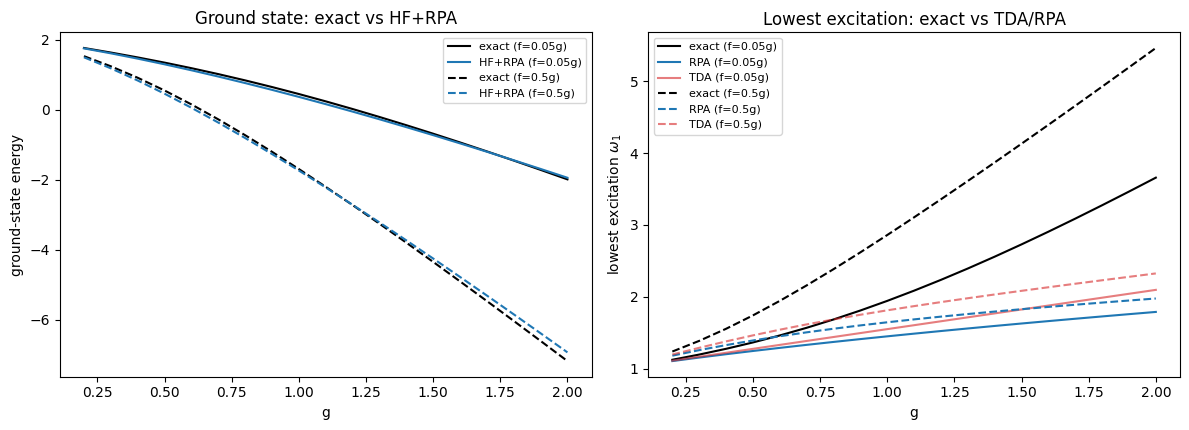

In [5]:
gs = np.linspace(0.2, 2.0, 19)
fig, ax = plt.subplots(1, 2, figsize=(12, 4.4))
for frac, style in [(0.05, '-'), (0.5, '--')]:
    E0e, E0r, w1e, w1t, w1r = [], [], [], [], []
    for g in gs:
        f = frac*g
        ex = exact_spectrum(L, N, g, f, k=2)
        r  = rpa_ph(L, N, g, f)
        E0e.append(ex[0]); E0r.append(r['Ehf']+r['Ecorr'])
        w1e.append(ex[1]-ex[0]); w1t.append(r['tda'][0]); w1r.append(r['rpa'][0])
    lab = f"f={frac}g"
    ax[0].plot(gs, E0e, 'k'+style, label=f"exact ({lab})")
    ax[0].plot(gs, E0r, 'C0'+style, label=f"HF+RPA ({lab})")
    ax[1].plot(gs, w1e, 'k'+style, label=f"exact ({lab})")
    ax[1].plot(gs, w1r, 'C0'+style, label=f"RPA ({lab})")
    ax[1].plot(gs, w1t, 'C3'+style, alpha=0.6, label=f"TDA ({lab})")
ax[0].set_xlabel("g"); ax[0].set_ylabel("ground-state energy"); ax[0].set_title("Ground state: exact vs HF+RPA"); ax[0].legend(fontsize=8)
ax[1].set_xlabel("g"); ax[1].set_ylabel(r"lowest excitation $\omega_1$"); ax[1].set_title("Lowest excitation: exact vs TDA/RPA"); ax[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

## 4. BCS: the pairing mean field

The pairing interaction is the standard separable pairing force $-G\sum_{pq}P^\dagger_pP_q$ with
$P^\dagger_p=a^\dagger_{p+}a^\dagger_{p-}$ and $G=g/2$. Its mean field is *not* of Hartree–Fock type — it
mixes states of different particle number — so we use the BCS trial state
$$
|{\rm BCS}\rangle=\prod_p\big(u_p+v_p\,a^\dagger_{p+}a^\dagger_{p-}\big)|0\rangle,\qquad u_p^2+v_p^2=1 .
$$
We fix $\{u_p,v_p\}$ by minimising $\langle{\rm BCS}|\hat H-\lambda\hat N|{\rm BCS}\rangle$ with $\lambda$ tuned
so that $\langle\hat N\rangle=N$. Doing the minimisation *directly on the Fock-space vector* sidesteps every
sign/self-energy convention in the analytic gap equations. The pairing gap is $\Delta=\tfrac{g}{2}\sum_p u_pv_p$.

In a finite system BCS shows a sharp normal→superfluid transition: below a critical $g_c$ the only solution
is the normal Fermi sea ($\Delta=0$), and above it a gap opens.

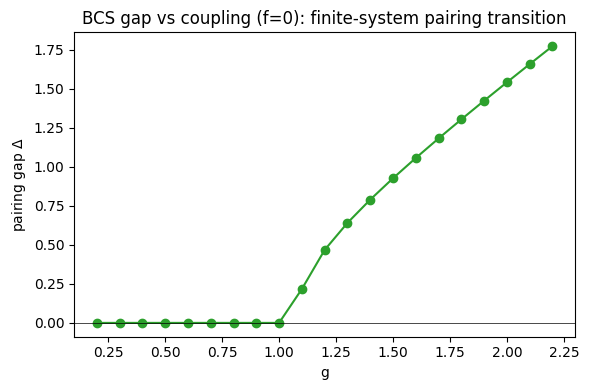

g=1.6:  Delta=1.056   lambda=1.100   <N>=4.0000   v^2=[0.9341 0.7835 0.2165 0.0659]


In [6]:
def bcs_variational(L, N, g, f=0.0, xi=1.0):
    H, cdag, c, dim = build_H_fock(L, g, f, xi)
    Nop = csr_matrix((dim, dim))
    for o in range(2*L):
        Nop = Nop + cdag[o] @ c[o]
    vac = np.zeros(dim); vac[0] = 1.0
    pairops = [cdag[oidx(p,UP)] @ cdag[oidx(p,DN)] for p in range(1, L+1)]
    def build_vec(theta):
        v = vac.copy()
        for p in range(L):
            v = np.cos(theta[p])*v + np.sin(theta[p])*(pairops[p] @ v)
        return v/np.linalg.norm(v)
    def routine(lam):
        def obj(theta):
            vec = build_vec(theta)
            return vec @ (H @ vec) - lam*(vec @ (Nop @ vec))
        th0 = np.array([1.4 if p < N//2 else 0.1 for p in range(L)])
        res = minimize(obj, th0, method='Powell', options={'xtol':1e-9, 'ftol':1e-11})
        vec = build_vec(res.x)
        return res.x, vec @ (Nop @ vec), vec
    lo, hi = -5.0, 10.0                      # bisect lambda to enforce <N>=N
    for _ in range(60):
        mid = 0.5*(lo+hi)
        th, Nbar, vec = routine(mid)
        if Nbar > N: hi = mid
        else:        lo = mid
        if abs(Nbar - N) < 1e-6: break
    u, v = np.abs(np.cos(th)), np.abs(np.sin(th))
    return dict(u=u, v=v, theta=th, lam=mid, Delta=(g/2)*np.sum(u*v),
                Ebcs=vec @ (H @ vec), Npart=Nbar, vec=vec)

gs2 = np.linspace(0.2, 2.2, 21)
deltas = [bcs_variational(L, N, g, 0.0)['Delta'] for g in gs2]
plt.figure(figsize=(6, 4))
plt.plot(gs2, deltas, 'o-', color='C2')
plt.axhline(0, color='k', lw=0.5)
plt.xlabel("g"); plt.ylabel(r"pairing gap $\Delta$")
plt.title("BCS gap vs coupling (f=0): finite-system pairing transition")
plt.tight_layout(); plt.show()
b = bcs_variational(L, N, 1.6, 0.0)
print(f"g=1.6:  Delta={b['Delta']:.3f}   lambda={b['lam']:.3f}   <N>={b['Npart']:.4f}   v^2={b['v']**2}")

## 5. Quasiparticle RPA

Bogoliubov quasiparticles diagonalise the pairing mean field,
$$
\alpha^\dagger_{p+}=u_p\,a^\dagger_{p+}-v_p\,a_{p-},\qquad
\alpha^\dagger_{p-}=u_p\,a^\dagger_{p-}+v_p\,a_{p+},
$$
and annihilate the BCS vacuum, $\alpha_{p\sigma}|{\rm BCS}\rangle=0$. QRPA builds collective modes from
*two-quasiparticle* pairs,
$$
\hat Q^\dagger_\nu=\sum_{a<b}\Big(X^\nu_{ab}\,\alpha^\dagger_a\alpha^\dagger_b-Y^\nu_{ab}\,\alpha_b\alpha_a\Big),
$$
with the same $\begin{pmatrix}A&B\\-B^*&-A^*\end{pmatrix}$ structure, now evaluated on $|{\rm BCS}\rangle$:
$$
A_{ab,cd}=\langle{\rm BCS}|[\alpha_b\alpha_a,[\hat H',\alpha^\dagger_c\alpha^\dagger_d]]|{\rm BCS}\rangle,\quad
B_{ab,cd}=-\langle{\rm BCS}|[\alpha_b\alpha_a,[\hat H',\alpha_d\alpha_c]]|{\rm BCS}\rangle .
$$

**Two subtleties handled below.**

* *Spurious mode.* BCS breaks $U(1)$ (particle-number) symmetry, so QRPA contains a spurious Goldstone mode
associated with $\hat N$. Building the QRPA with the **cranked Hamiltonian** $\hat H'=\hat H-\lambda\hat N$
(the same $\lambda$ that BCS extremises) pushes this mode to $\omega\approx0$, where we discard it.

* *Mode content.* Because quasiparticles mix particle number, QRPA phonons come in two flavours: $\Delta N=0$
excitations *of the $N$-particle system* and $\Delta N=\pm2$ **pairing vibrations** connecting to the
$N\pm2$ systems. Only the former are directly comparable to the exact within-$N$ spectrum.

In [7]:
def bcs_vacuum_and_qp(L, bcs):
    cdag, c, dim = build_c_ops(L)
    u, v = bcs['u'], bcs['v']
    vac = np.zeros(dim); vac[0] = 1.0
    bcsvec = vac.copy()
    for p in range(1, L+1):
        pair = cdag[oidx(p,UP)] @ cdag[oidx(p,DN)]
        bcsvec = u[p-1]*bcsvec + v[p-1]*(pair @ bcsvec)
    bcsvec /= np.linalg.norm(bcsvec)
    adag = {}
    for p in range(1, L+1):
        up, vp = u[p-1], v[p-1]
        adag[(p,UP)] = up*cdag[oidx(p,UP)] - vp*c[oidx(p,DN)]
        adag[(p,DN)] = up*cdag[oidx(p,DN)] + vp*c[oidx(p,UP)]
    labels = [(p, s) for p in range(1, L+1) for s in (UP, DN)]
    return bcsvec, adag, labels, dim

def qrpa(L, N, g, f, xi=1.0):
    H, cdag, c, dim = build_H_fock(L, g, f, xi)
    Nop = csr_matrix((dim, dim))
    for o in range(2*L):
        Nop = Nop + cdag[o] @ c[o]
    b = bcs_variational(L, N, g, f, xi)
    Hp = H - b['lam']*Nop                                   # cranked -> spurious mode to zero
    bcsvec, adag, labels, dim = bcs_vacuum_and_qp(L, b)
    Oops = [adag[labels[a]] @ adag[labels[bb]]
            for a in range(len(labels)) for bb in range(a+1, len(labels))]
    A, B = build_AB(Hp, bcsvec, Oops)
    pos, n_imag, _ = solve_rpa(A, B, tol=1e-2)              # tol drops the ~0 Goldstone mode
    Ecorr = 0.5*(pos.sum() - np.trace(A)) if n_imag == 0 else np.nan
    return dict(Ebcs=b['Ebcs'], Delta=b['Delta'], lam=b['lam'],
                omega=pos, Ecorr=Ecorr, n_imag=n_imag, stable=(n_imag == 0))

# verify the quasiparticles annihilate the BCS vacuum, and show a QRPA spectrum
b = bcs_variational(L, N, 1.6, 0.0)
bcsvec, adag, labels, dim = bcs_vacuum_and_qp(L, b)
ann = max(np.linalg.norm(adag[lb].conj().T @ bcsvec) for lb in labels)
print(f"max ||alpha_a |BCS>||  = {ann:.2e}   (should be ~0)")
q = qrpa(L, N, 1.6, 0.0)
print(f"g=1.6, f=0:  Delta={q['Delta']:.3f}   stable={q['stable']}   lowest QRPA omegas={q['omega'][:5]}")

max ||alpha_a |BCS>||  = 3.42e-17   (should be ~0)


g=1.6, f=0:  Delta=1.056   stable=True   lowest QRPA omegas=[1.7647 2.2308 2.2308 2.2308 2.2308]


## 6. Putting it together: exact vs ph-RPA vs QRPA

For the **pure-pairing** line ($f=0$) we compare the correlated ground-state energies. Two lessons stand out,
and both are on-message for a study of many-body approximations:

* Away from the transition, QRPA adds pairing correlations on top of BCS and moves the energy toward the
exact result; like RPA it tends to **overcorrelate**, and the discrepancy grows as collective modes soften.

* Near the mean-field transition (and again at strong coupling, where two-quasiparticle levels cross) the
QRPA matrix develops **imaginary eigenvalues** — the small-amplitude expansion around a single BCS/HF
reference has broken down. We mark those regions rather than quoting a correlation energy there.

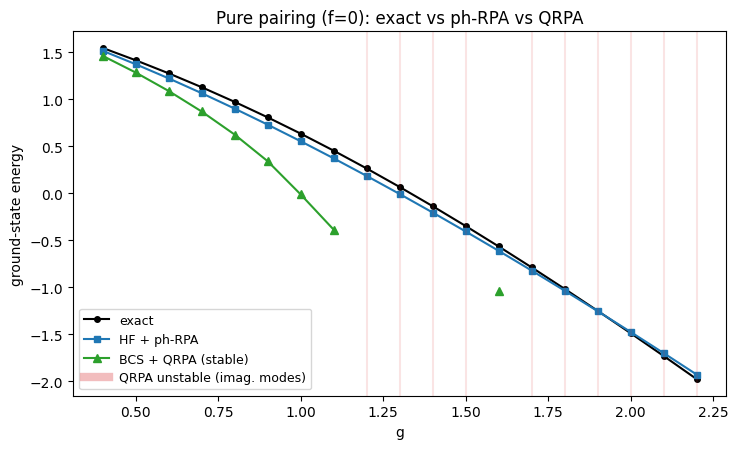

 g     exact      HF+RPA     BCS+QRPA    QRPA-stable
0.40     1.5480     1.5175     1.4637    True
0.50     1.4168     1.3745     1.2863    True
0.60     1.2774     1.2239     1.0896    True
0.70     1.1298     1.0662     0.8710    True
0.80     0.9736     0.9018     0.6254    True
0.90     0.8088     0.7311     0.3420    True
1.00     0.6355     0.5546    -0.0116    True
1.10     0.4540     0.3725    -0.3867    True
1.20     0.2645     0.1851        nan    False
1.30     0.0673    -0.0073        nan    False
1.40    -0.1370    -0.2045        nan    False
1.50    -0.3482    -0.4062        nan    False
1.60    -0.5657    -0.6123    -1.0435    True
1.70    -0.7890    -0.8225        nan    False
1.80    -1.0177    -1.0367        nan    False
1.90    -1.2514    -1.2546        nan    False
2.00    -1.4897    -1.4762        nan    False
2.10    -1.7321    -1.7013        nan    False
2.20    -1.9784    -1.9298        nan    False


In [8]:
gs3 = np.linspace(0.4, 2.2, 19)
E0e, E0r, E0q, stab = [], [], [], []
for g in gs3:
    E0e.append(exact_spectrum(L, N, g, 0.0, k=1)[0])
    r = rpa_ph(L, N, g, 0.0); E0r.append(r['Ehf']+r['Ecorr'])
    q = qrpa(L, N, g, 0.0)
    E0q.append(q['Ebcs']+q['Ecorr'] if q['stable'] else np.nan)
    stab.append(q['stable'])

plt.figure(figsize=(7.5, 4.6))
plt.plot(gs3, E0e, 'k-o', label="exact", ms=4)
plt.plot(gs3, E0r, 'C0-s', label="HF + ph-RPA", ms=4)
plt.plot(gs3, E0q, 'C2-^', label="BCS + QRPA (stable)", ms=6)
for g, s in zip(gs3, stab):
    if not s:
        plt.axvline(g, color='C3', alpha=0.12)
plt.plot([], [], color='C3', alpha=0.3, lw=6, label="QRPA unstable (imag. modes)")
plt.xlabel("g"); plt.ylabel("ground-state energy"); plt.title("Pure pairing (f=0): exact vs ph-RPA vs QRPA")
plt.legend(fontsize=9); plt.tight_layout(); plt.show()

print(" g     exact      HF+RPA     BCS+QRPA    QRPA-stable")
for g, e, rr, qq, s in zip(gs3, E0e, E0r, E0q, stab):
    print(f"{g:4.2f}  {e:9.4f}  {rr:9.4f}  {qq:9.4f}    {s}")

## 7. Discussion and next steps

* **ph-RPA/TDA** (Sec. 3) is the right tool for the particle–hole channel: built on a stationary HF state,
it is numerically stable across the whole coupling range and captures density-type excitations plus their
ground-state correlations. It has no access to pairing correlations, which is visible in the excitation
spectrum.

* **BCS + QRPA** (Sec. 4–5) targets the pairing channel. The variational BCS vacuum exposes the finite-system
pairing transition, and QRPA restores fluctuations around it. The **spurious number mode** is controlled by
cranking with $\hat H-\lambda\hat N$, and QRPA phonons split into $\Delta N=0$ excitations and $\Delta N=\pm2$
pairing vibrations.

* **Where the approximations break.** The clearest physics result here is the appearance of **imaginary QRPA
modes** near the transition and at strong coupling. In a small system like $N=L=4$ the collective modes are
few and soften quickly, so RPA/QRPA overcorrelate and eventually collapse. This is not a bug — it is the
signal that a single symmetry-broken reference plus small-amplitude fluctuations is no longer adequate, and
that a fully self-consistent **HFB + QRPA** (treating the pairing *and* particle–hole mean fields together,
so that a combined $f\neq0$, $g\neq0$ calculation is stationary) or a beyond-RPA / exact treatment is required.
That interplay of correlations, and the limits of truncated many-body expansions, is exactly the theme of the
underlying paper.

* **Performance / language port.** As in the exact-diagonalisation notebook, the heavy objects are the sparse
Fock-space operators and the double-commutator evaluations. These map cleanly onto an object-oriented
C++/Fortran layer (an `Operator` class wrapping sparse storage, with `commutator` and expectation-value
kernels), exposed to Python for orchestration — the recommended next step.